In [27]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
vnlegal_corpus = load_from_disk("./raw/vnlegal_corpus")
vnlegal_qa = load_from_disk("./raw/vnlegal_qa")
vnlegal_corpus[0], len(vnlegal_corpus), vnlegal_qa[0], len(vnlegal_qa)

({'passage_id': 'luat_ia_chat_va_khoang_san_cua_quoc_hoi_so_54_2024_qh15_dieu_5_8a08edb9',
  'doc_name': 'Luật Địa chất và Khoáng sản của Quốc hội, số 54/2024/QH15',
  'article_content': 'Điều 5. Nguyên tắc hội nhập và hợp tác quốc tế về địa chất, khoáng sản\n\n1. Hội nhập và hợp tác quốc tế trong nghiên cứu, điều tra cơ bản địa chất, điều tra địa chất về khoáng sản, hoạt động khoáng sản, quản lý hoạt động khoáng sản phải đặt trong tổng thể chiến lược phát triển kinh tế - xã hội của đất nước trong từng thời kỳ; chiến lược địa chất, khoáng sản và công nghiệp khai khoáng; tuân thủ Hiến pháp, pháp luật Việt Nam, Hiến chương Liên hợp quốc, điều ước quốc tế mà nước Cộng hòa xã hội chủ nghĩa Việt Nam là thành viên, bảo đảm phù hợp với đường lối và chính sách đối ngoại của Việt Nam; bảo đảm nguyên tắc hợp tác bình đẳng, cùng có lợi trên cơ sở tôn trọng độc lập, chủ quyền và toàn vẹn lãnh thổ, không can thiệp vào công việc nội bộ của nhau.\n\n2. Tranh chấp quốc tế về địa chất, khoáng sản được 

In [29]:
corpus_df = vnlegal_corpus.to_pandas()
qa_df = vnlegal_qa.to_pandas()

## Simple check

In [30]:
# Check null values in corpus
null_counts = corpus_df.isnull().sum()
print("Null value counts in VNLegal Corpus:")
print(null_counts)

Null value counts in VNLegal Corpus:
passage_id         0
doc_name           0
article_content    0
macro_domain       0
dtype: int64


In [31]:
# Check null values in qa
null_counts_qa = qa_df.isnull().sum()
print("Null value counts in VNLegal QA:")
print(null_counts_qa)

Null value counts in VNLegal QA:
qa_id            0
passage_id       0
question         0
answer           0
question_type    0
difficulty       0
macro_domain     0
dtype: int64


In [32]:
# Check duplication in corpus
corpus_df["passage_id"].duplicated().sum()

np.int64(0)

In [33]:
# check if each passage_id has 3 questions
qa_df["question_count"] = qa_df.groupby("passage_id")["question"].transform("count")
qa_df["question_count"].value_counts()

question_count
3    29145
Name: count, dtype: int64

## Data quality

/var/folders/8b/ktndfm5s68739w9cvkrwvnj00000gp/T/ipykernel_94371/2254913394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.index, y=domain_counts.values, palette="viridis")


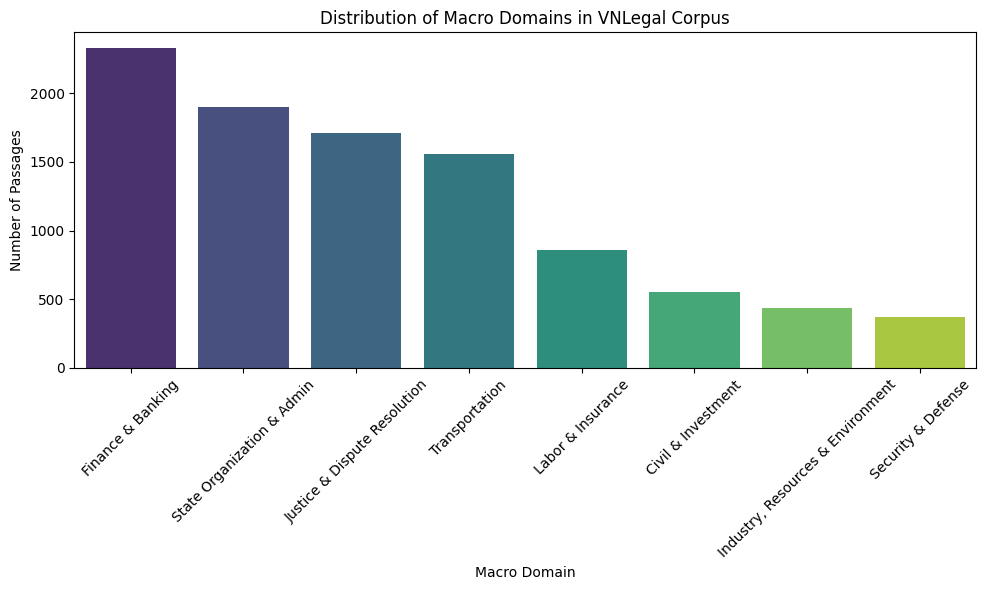

In [34]:
# Distribution of macro_domain
domain_counts = corpus_df["macro_domain"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=domain_counts.index, y=domain_counts.values, palette="viridis")
plt.title("Distribution of Macro Domains in VNLegal Corpus")
plt.xlabel("Macro Domain")
plt.ylabel("Number of Passages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
question_type_counts = qa_df["question_type"].value_counts()
print(question_type_counts)

question_type
factual           9746
application       7522
interpretation    6439
analytical        5435
Thực tế              1
Giải thích           1
Ứng dụng             1
Name: count, dtype: int64


In [36]:
QUESTION_TYPE_MAP = {
    "thực tế": "factual",
    "giải thích": "interpretation",
    "ứng dụng": "application",
    "phân tích": "analytical",
}

qa_df["question_type"] = (
    qa_df["question_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(QUESTION_TYPE_MAP)
)

print(qa_df["question_type"].value_counts())

question_type
factual           9747
application       7523
interpretation    6440
analytical        5435
Name: count, dtype: int64


/var/folders/8b/ktndfm5s68739w9cvkrwvnj00000gp/T/ipykernel_94371/1585346143.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=question_type_counts.index, y=question_type_counts.values, palette="magma")


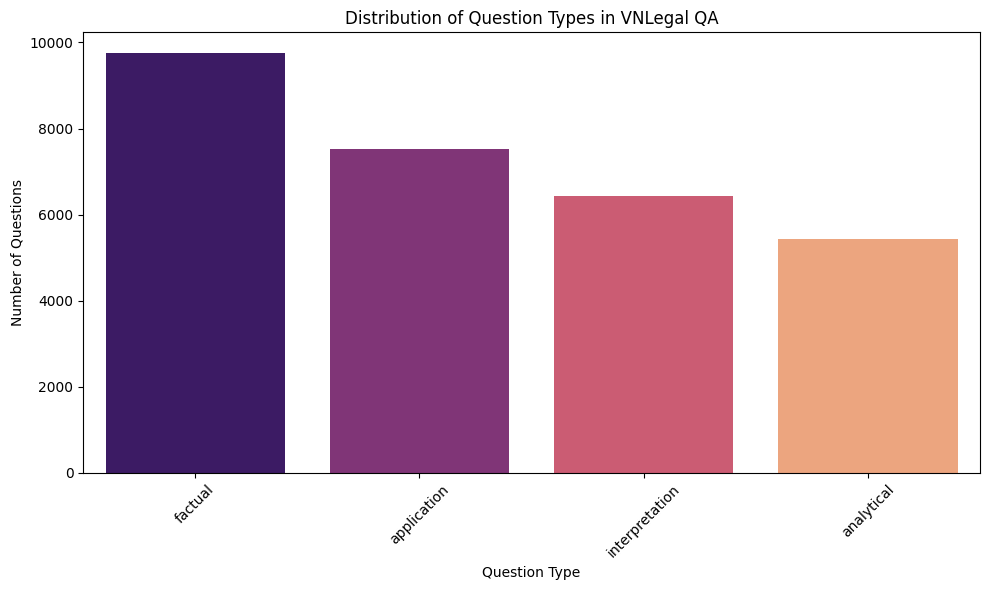

In [37]:
# Distribution of question types
question_type_counts = qa_df["question_type"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=question_type_counts.index, y=question_type_counts.values, palette="magma")
plt.title("Distribution of Question Types in VNLegal QA")
plt.xlabel("Question Type")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [38]:
# 